/Users/niks/.pyenv/versions/my-safe-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📊 Loading engineered dataset...
🌲 Training Isolation Forest...

Isolation Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1957
           1       0.80      0.84      0.82        43

    accuracy                           0.99      2000
   macro avg       0.90      0.92      0.91      2000
weighted avg       0.99      0.99      0.99      2000


⚡ Training XGBoost Classifier...

XGBoost ROC-AUC Score: 1.0000

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1957
           1       0.98      1.00      0.99        43

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000


🧠 Generating SHAP Explanations...


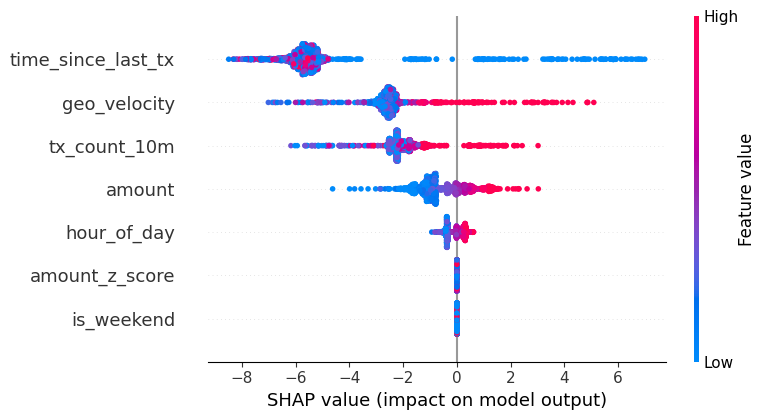


💾 Exporting models to production backend...
✅ Complete! Models are ready for the FastAPI server.


In [1]:
# 1. Imports
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Prepare Data
print("📊 Loading engineered dataset...")
engineered_df = pd.read_csv('../data/engineered_data.csv')

# NEW: Added 'time_since_last_tx' to match our updated enterprise schema
features = [
    'amount', 
    'geo_velocity', 
    'time_since_last_tx', 
    'tx_count_10m', 
    'hour_of_day', 
    'is_weekend', 
    'amount_z_score'
]

X = engineered_df[features]
y = engineered_df['Class']

# ENTERPRISE FIX: Split data FIRST to prevent data leakage, THEN scale.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale features (Fit only on training data to maintain test integrity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model 1: Isolation Forest (Unsupervised Anomaly Detection)
print("🌲 Training Isolation Forest...")
iso_forest = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso_forest.fit(X_train_scaled)

# Convert Isolation Forest output (-1 for anomaly, 1 for normal) to binary (1 for fraud, 0 for normal)
iso_predictions = np.where(iso_forest.predict(X_test_scaled) == -1, 1, 0)
print("\nIsolation Forest Report:")
print(classification_report(y_test, iso_predictions))

# 4. Model 2: XGBoost Classifier (Supervised)
print("\n⚡ Training XGBoost Classifier...")
# Calculate scale_pos_weight to handle the heavy class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Evaluate XGBoost
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred = xgb_model.predict(X_test_scaled)

print(f"\nXGBoost ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Model Explainability (SHAP)
print("\n🧠 Generating SHAP Explanations...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Plot summary of feature importance
# Convert scaled array back to DataFrame just for beautiful SHAP plotting labels
shap.summary_plot(shap_values, pd.DataFrame(X_test_scaled, columns=features))

# 6. Export Artifacts for Production Backend
print("\n💾 Exporting models to production backend...")

# Safely create the directory if it doesn't exist
models_dir = '../../backend/app/ml/models/'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(scaler, f'{models_dir}scaler.pkl')
joblib.dump(iso_forest, f'{models_dir}isolation_forest.pkl')
joblib.dump(xgb_model, f'{models_dir}xgboost_classifier.pkl')
joblib.dump(features, f'{models_dir}feature_columns.pkl')

print("✅ Complete! Models are ready for the FastAPI server.")